# GAN to generate data accroding to a sinus distribution

Generative adversarial networks consist of an overall structure composed of two neural networks, one called the generator and the other called the discriminator.

The role of the generator is to estimate the probability distribution of the real samples in order to provide generated samples resembling real data. The discriminator, in turn, is trained to estimate the probability that a given sample came from the real data rather than being provided by the generator.

These structures are called generative adversarial networks because the generator and discriminator are trained to compete with each other: the generator tries to get better at fooling the discriminator, while the discriminator tries to get better at identifying generated samples.

## course reminders

### Data
Consider an example with a dataset composed of two-dimensional samples $(x_1, x_2)$, with $x_1$ in the interval from 0 to $2\pi$ and $x_2 = \sin(x_1)$.

### Generator
The generator G is fed with random data from a latent space, and its role is to generate data resembling the real samples. In this example, you have a two-dimensional latent space, so that the generator is fed with random $(z_1, z_2)$ pairs and is required to transform them so that they resemble the real samples.

### Discriminator
The discriminator D is fed with either real samples from the training dataset or generated samples provided by G. Its role is to estimate the probability that the input belongs to the real dataset. The training is performed so that D outputs 1 when it’s fed a real sample and 0 when it’s fed a generated sample. In this example, the input is two-dimensional. For a binary discriminator, the output may be a scalar ranging from 0 to 1.

### Training process

The GAN training process consists of a two-player minimax game in which D is adapted to minimize the discrimination error between real and generated samples, and G is adapted to maximize the probability of D making a mistake.

Although the dataset containing the real data isn’t labeled, the training processes for D and G are performed in a supervised way. At each step in the training, D and G have their parameters updated. In fact, in the original GAN proposal, the parameters of D are updated k times, while the parameters of G are updated only once for each training step. However, to make the training simpler, you can consider k equal to 1.

To train D, at each iteration you label some real samples taken from the training data as 1 and some generated samples provided by G as 0. This way, you can use a conventional supervised training framework to update the parameters of D in order to minimize a loss function.

For each batch of training data containing labeled real and generated samples, you update the parameters of D to minimize a loss function. After the parameters of D are updated, you train G to produce better generated samples. The output of G is connected to D, whose parameters are kept frozen.

You can imagine the system composed of G and D as a single classification system that receives random samples as input and outputs the classification, which in this case can be interpreted as a probability.

When G does a good enough job to fool D, the output probability should be close to 1. You could also use a conventional supervised training framework here: the dataset to train the classification system composed of G and D would be provided by random input samples, and the label associated with each input sample would be 1.

During training, as the parameters of D and G are updated, it’s expected that the generated samples given by G will more closely resemble the real data, and D will have more trouble distinguishing between real and generated data.

 ## Implementation
 
 ### Import the necessary libraries

In [ ]:
# Test and install packages
import subprocess

def install_package(package):
    subprocess.call(['conda', 'install', '-c', 'conda-forge', package])


package_name=['torch', 'math', 'matplotlib', 'time']
for i in range(len(package_name)):
    check_package = subprocess.run(['conda', 'list', package_name[i]], stdout=subprocess.PIPE)
    #print(check_package.returncode)
    if check_package.returncode is None:
        print(package_name[i] +" is not installed --- Starting the install")
        install_package(package_name[i])
    else: 
        print(package_name[i] +" is installed")

In [1]:
import torch
from torch import nn

import math
import time

import matplotlib.pyplot as plt
from IPython.display import clear_output

### General parameters 

In [2]:
# Training epochs to be performed
Nb_epochs = 300

# Discriminator updates per generator update
d_updates = 1

# Frequency of epochs to produce plots.
plot_frequency = 10

# Learning rate to be applied
lr = 0.0001

# Size of latent vector to be utilized
latent_size = 2

#Number of samples from the real distribution
train_data_length = 5000

# Batch size to be utilized
batch_size = 100

### Training Data
The training data is composed of pairs $(x_1, x_2)$, with $x_1$ in the interval from 0 to $2\pi$ and $x_2 = \sin(x_1)$.

In [3]:
# initialize train_data, a tensor with dimensions of 1024 rows and 2 columns, all containing zeros
train_data = torch.zeros((train_data_length, 2))

# the first column of train_data store random values in the interval from 0 to 2π. 
train_data[:, 0] = 2 * math.pi * torch.rand(train_data_length)

# the second column of the tensor train_data store the corresponding sine values
train_data[:, 1] = torch.sin(train_data[:, 0])

# we need a tensor of labels, which are also required by PyTorch’s data loader. 
train_labels = torch.ones(train_data_length,1)

# create train_set as a list of tuples, with each row of train_data and train_labels represented in each tuple 
# as expected by PyTorch’s data loader.
train_set = [(train_data[i], train_labels[i]) for i in range(train_data_length)]

You can examine the training data by plotting each point $(x_1, x_2)$

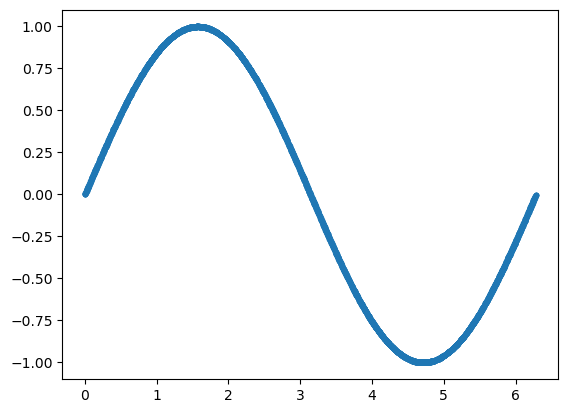

In [4]:
plt.plot(train_data[:, 0], train_data[:, 1], ".")

Create PyTorch data loader called train_loader, which will shuffle the data from train_set and return batches of batch_size samples that you’ll use to train the neural networks.

In [5]:
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True, drop_last=True
)
# drop_last=True to drop the last incomplete batch when the number of examples are not exactly divided by the batch size

### Implementing the Discriminator
The discriminator is a model with a two-dimensional input and a one-dimensional output. It’ll receive a sample from the real data or from the generator and will provide the probability that the sample belongs to the real training data.

In [6]:
class Discriminator(nn.Module):
    # build the model
    def __init__(self):
        # we need to call super().__init__() to run .__init__() from nn.Module from nn.Module
        # used to initialize the parameters of the network
        super().__init__()
        # Define the Discriminator model
        self.model = nn.Sequential(
            nn.Linear(2, 256), # nn.Linear(in_features, out_features, bias=True, device=None, dtype=None)
            nn.ReLU(), # activation function
            nn.Dropout(0.3), # nn.Dropout(p=0.5, inplace=False) to avoid overfitting
                             # randomly zeroes some of the elements of the input tensor with probability p.
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid(), # sigmoidal activation to represent a probability (scalar beween [0, 1])
        )

    # describe how the output of the model is calculated
    # x represents the input of the model, which is a two-dimensional tensor. 
    # the output is obtained by feeding the input x to the model
    def forward(self, x):
        output = self.model(x)
        return output

### Implementing the Generator
The generator is the model that takes samples from a latent space as its input and generates data resembling the data in the training set. Here it’s a model with a two-dimensional input, which will receive random points $(z_1, z_2)$, and a two-dimensional output that must provide $(\tilde{x}_2, \tilde{x}_2)$ points resembling those from the training data.

In [7]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_size, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
        )

    # the output will consist of a vector with two elements that can be any value 
    # ranging from negative infinity to infinity, which will represent $(\tilde{x}_2, \tilde{x}_2)$
    def forward(self, x):
        output = self.model(x)
        return output

### Instantiate the Discriminator and Generator objects

In [8]:
discriminator = Discriminator()
generator = Generator()

# Display the models
print(discriminator)
print(generator)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=64, out_features=1, bias=True)
    (10): Sigmoid()
  )
)
Generator(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


### Loss function and optimizers

With $D$ and $G$ setup, we can specify how they learn through the loss functions and optimizers. 

The Binary Cross Entropy function is a suitable loss function for training the discriminator because it considers a binary classification task. It’s also suitable for training the generator since it feeds its output to the discriminator, which provides a binary observable output. The Binary Cross Entropy loss ([BCELoss](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html#torch.nn.BCELoss)_) is defined in PyTorch as:

\begin{align}\ell(x, y) = L = \{l_1,\dots,l_N\}^\top, \quad l_n = - \left[ y_n \cdot \log x_n + (1 - y_n) \cdot \log (1 - x_n) \right]\end{align}

Notice how this function provides the calculation of both log components in the objective function (i.e. $log(D(x))$ and
$log(1-D(G(z)))$). We can specify what part of the BCE equation to
use with the $y$ input. This is accomplished in the training loop, but it is important to understand how we can
choose which component we wish to calculate just by changing $y$ (i.e. GT labels), especially when using the non-saturating loss for the generator (adjust G’s objective function to maximize $log(D(G(z)))$ ). Indeed, using the real labels as ground truth labels for the Generator loss function allows us to use the $log(x)$ part of the ``BCELoss`` (rather than the $log(1-x)$ part), which is exactly what we want for the non-saturating loss.

We define our real label as 1 and the fake label as 0. These labels will be used when calculating the losses of $D$ and $G$. 

Finally, we set up two separate optimizers, one for $D$ and
one for $G$. We use Adam, which is more efficient than SGD.

In the training loop, we will monitor the losses to check convergence.


In [9]:
# binary cross-entropy function used to train the model
loss_function = nn.BCELoss()

# use Adam optimizer
optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

### Custom the weights initialization

In [10]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
    elif classname.find('Linear') != -1:
        nn.init.xavier_uniform_(m.weight.data)

generator.apply(weights_init)
discriminator.apply(weights_init)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=64, out_features=1, bias=True)
    (10): Sigmoid()
  )
)

### Training loop

For GANs, you update the parameters of the discriminator and the generator at each training iteration. As is generally done for all neural networks, the training process consists of two loops, one for the training epochs and the other for the batches for each epoch.

Note: if you want to run the training loop several times from scratch do not forgot to run the weigths initialization

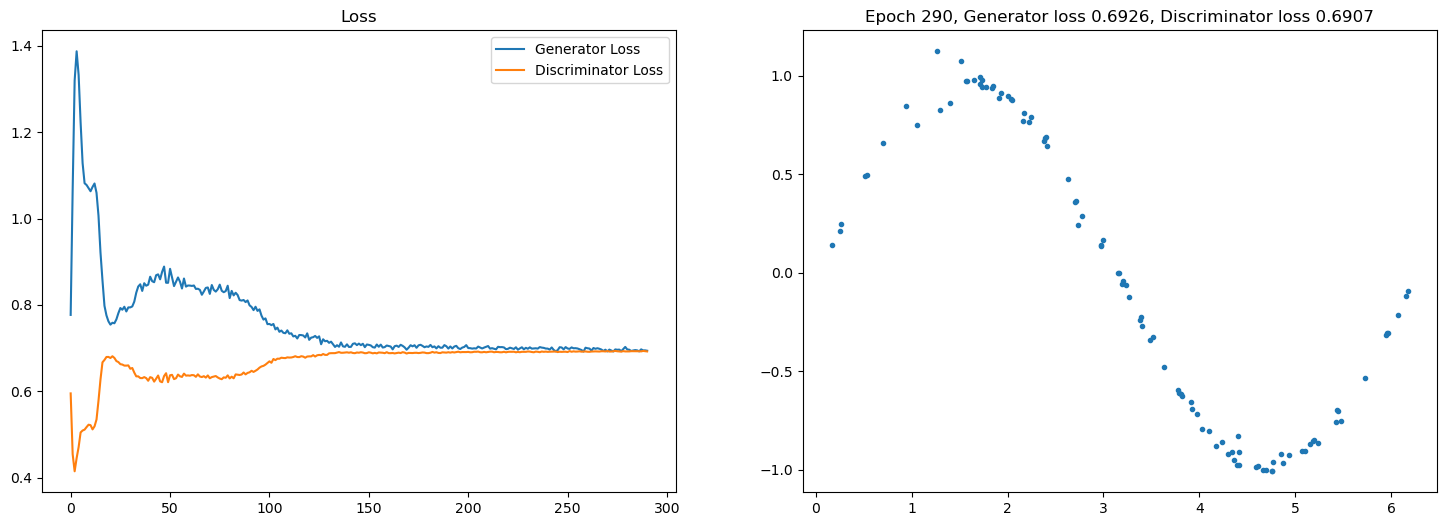

In [11]:
# Set models to train mode
generator.train()
discriminator.train()

# we display the generated distribution and the loss values on the different graphes
# here the mean loss is computed at the end of each epoch and saved 
loss_gen, loss_dis = [],[]

# Loop over the epochs
for epoch in range(Nb_epochs):
    loss_gen_run, loss_dis_run = 0, 0
    
    # get the real samples of the current batch from the data loader and assign them to real_samples
    for n, (real_samples, real_samples_labels) in enumerate(train_loader):
        
        #--- Data for training the discriminator ---#
        # create the generated samples by storing random data in latent_space_samples
        latent_space_samples = torch.randn((batch_size, 2))

        # Disabling gradient calculation for inference in the block (temporarily sets all of the requires_grad flags to false)
        # reduce memory consumption for computations (the gradients are not used during discriminator training - the generator is frozen)
        with torch.no_grad(): 
            generated_samples = generator(latent_space_samples)
            
        # create the labels with value 0 for the generated samples
        generated_samples_labels = torch.zeros((batch_size, 1))

        #--- Training the discriminator ---#
        #  In PyTorch, it’s necessary to clear the gradients at each training step to avoid accumulating them
        # Use model.zero_grad(). This is the same as using optimizer.zero_grad() as long as all your model parameters are in that optimizer. 
        discriminator.zero_grad()

        # calculate the output of the discriminator using the training data
        output_real = discriminator(real_samples)
        output_fake = discriminator(generated_samples)
        
        # calculate the loss function using the output from the model (predicted labels) and the true labels
        loss_real = loss_function(output_real, real_samples_labels)
        loss_fake = loss_function(output_fake, generated_samples_labels)

        loss_discriminator=(loss_real+loss_fake)/2
        
        # calculate the gradients to update the weights 
        loss_discriminator.backward()

        #  update the discriminator weights (the weigths of the generator are frozen)
        optimizer_discriminator.step()

        #--- Data for training the generator ---#
        # store random data 
        # number of lines equal to batch_size - two columns since we’re providing two-dimensional data as input
        latent_space_samples = torch.randn((batch_size, 2))

        #--- Training the generator ---#
        # clear the gradients
        generator.zero_grad()
        
        # generate new data
        generated_samples = generator(latent_space_samples)
        
        # calculate the output of the discriminator using the generated data
        output_discriminator_generated = discriminator(generated_samples)
        
        # calculate the loss function using the output of the classification system and the labels, which are all equal to 1
        # to fool the discriminator: Non-saturating loss
        loss_generator = loss_function(output_discriminator_generated, real_samples_labels)
        
        # calculate the gradients
        loss_generator.backward()
        
        # update the generator weights
        optimizer_generator.step()
        # Remember that when you trained the generator, you kept the discriminator weights frozen since (but we need its gradients)
        # we created optimizer_generator with its first argument equal to generator.parameters().
        
        # save loss values
        loss_gen_run+=loss_generator.detach() # use .detach(): returns a new Tensor, detached from the current graph.
        loss_dis_run +=loss_discriminator.detach()
        
    # compute the mean at the end of the batch and store it (to be displayed later)
    loss_gen.append(loss_gen_run/len(train_loader)) 
    loss_dis.append(loss_dis_run/len(train_loader)) 
            
    # Show sometime the discriminator and generator loss
    if epoch % plot_frequency == 0:
        # turn the generator to eval mode (not necessary to do that but better to do it...)
        generator.eval()
            
        fig, ax = plt.subplots(1,2,figsize=(18,6))
        # plot Loss
        ax[0].plot(loss_gen,label='Generator Loss')
        ax[0].plot(loss_dis,label='Discriminator Loss')
        ax[0].set_title('Loss')
        ax[0].legend()

        # get some random samples from the latent space
        latent_space_samples = torch.randn(100, 2)
            
        # feed them to the generator to obtain some generated samples
        with torch.no_grad():
            generated_samples = generator(latent_space_samples)

        # plot generated smples
        ax[1].plot(generated_samples[:, 0], generated_samples[:, 1], ".")
        ax[1].set_title('Epoch {}, Generator loss {:.4f}, Discriminator loss {:.4f}'.format((epoch), loss_discriminator, loss_generator))
            
        clear_output(wait=True)
        plt.show()

        # turn back the generator to train mode
        generator.train()
            

## Display new samples generated by the GAN

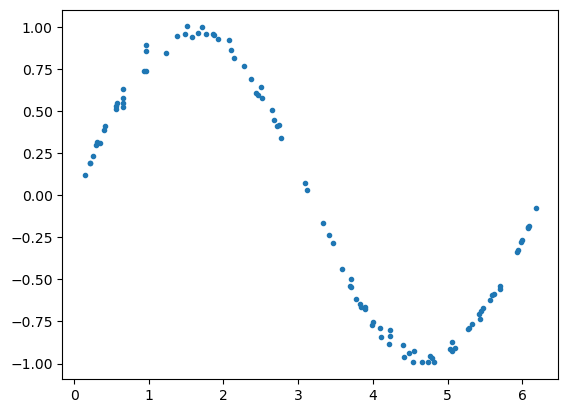

In [12]:
generator.eval()

# get some random samples from the latent space
latent_space_samples = torch.randn(100, 2)
# feed them to the generator to obtain some generated samples
generated_samples = generator(latent_space_samples)

# use .detach(): returns a new Tensor, detached from the current graph.
generated_samples = generated_samples.detach()
plt.plot(generated_samples[:, 0], generated_samples[:, 1], ".")